In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path
import os
import json
import random
import pickle
import datetime
import platform
import importlib.metadata as im

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

BASE = Path("/content/drive/MyDrive/New Jurnal Cross")

E2V_DIR = BASE / "processed_intra_features_e2v_plus_base"
OUT_DIR = BASE / "results_directional_transfer_emotion2vec_plus_base"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["emodb", "ravdess", "resd"]
DATASET_LABEL = {
    "emodb": "EMODB",
    "ravdess": "RAVDESS",
    "resd": "RESD",
}

LABELS = ["angry", "disgust", "fear", "happy", "neutral", "sad"]
ID_TO_LABEL = {i: label for i, label in enumerate(LABELS)}

SEEDS = [42, 123, 2024]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("E2V_DIR:", E2V_DIR)
print("OUT_DIR:", OUT_DIR)
print("DEVICE :", DEVICE)

Mounted at /content/drive
E2V_DIR: /content/drive/MyDrive/New Jurnal Cross/processed_intra_features_e2v_plus_base
OUT_DIR: /content/drive/MyDrive/New Jurnal Cross/results_directional_transfer_emotion2vec_plus_base
DEVICE : cuda


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def pkg_ver(name):
    try:
        return im.version(name)
    except Exception:
        return "not installed"


def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred) * 100.0,
        "UAR": recall_score(y_true, y_pred, average="macro", zero_division=0) * 100.0,
        "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100.0,
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100.0,
    }


def make_report_df(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T


def save_confusion_matrix_csv(cm, path):
    cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)
    cm_df.to_csv(path)


class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class Emotion2VecMLP(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_classes=6, dropout=0.30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [3]:
def load_e2v_dataset(dataset_name):
    ds_dir = E2V_DIR / dataset_name

    required = [
        ds_dir / "X_e2v_train.npy",
        ds_dir / "X_e2v_val.npy",
        ds_dir / "X_e2v_test.npy",
        ds_dir / "y_train.npy",
        ds_dir / "y_val.npy",
        ds_dir / "y_test.npy",
        ds_dir / "meta_train.csv",
        ds_dir / "meta_val.csv",
        ds_dir / "meta_test.csv",
    ]

    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing files:\n" + "\n".join(missing))

    data = {
        "X_train": np.load(ds_dir / "X_e2v_train.npy").astype(np.float32),
        "X_val": np.load(ds_dir / "X_e2v_val.npy").astype(np.float32),
        "X_test": np.load(ds_dir / "X_e2v_test.npy").astype(np.float32),
        "y_train": np.load(ds_dir / "y_train.npy").astype(int),
        "y_val": np.load(ds_dir / "y_val.npy").astype(int),
        "y_test": np.load(ds_dir / "y_test.npy").astype(int),
        "meta_train": pd.read_csv(ds_dir / "meta_train.csv"),
        "meta_val": pd.read_csv(ds_dir / "meta_val.csv"),
        "meta_test": pd.read_csv(ds_dir / "meta_test.csv"),
    }

    return data


all_data = {ds: load_e2v_dataset(ds) for ds in DATASETS}

for ds, d in all_data.items():
    print(ds)
    print(" train:", d["X_train"].shape, d["y_train"].shape)
    print(" val  :", d["X_val"].shape, d["y_val"].shape)
    print(" test :", d["X_test"].shape, d["y_test"].shape)

emodb
 train: (498, 768) (498,)
 val  : (71, 768) (71,)
 test : (149, 768) (149,)
ravdess
 train: (704, 768) (704,)
 val  : (176, 768) (176,)
 test : (176, 768) (176,)
resd
 train: (873, 768) (873,)
 val  : (186, 768) (186,)
 test : (139, 768) (139,)


In [4]:
def make_directional_fold(source_dataset, target_dataset):
    source = all_data[source_dataset]
    target = all_data[target_dataset]

    # Source train = source train + source test
    X_train_raw = np.concatenate(
        [source["X_train"], source["X_test"]],
        axis=0
    )
    y_train = np.concatenate(
        [source["y_train"], source["y_test"]],
        axis=0
    )

    meta_train = pd.concat(
        [source["meta_train"], source["meta_test"]],
        axis=0,
        ignore_index=True
    )
    meta_train["directional_role"] = "source_train"

    # Source validation = source val
    X_val_raw = source["X_val"]
    y_val = source["y_val"]
    meta_val = source["meta_val"].copy()
    meta_val["directional_role"] = "source_validation"

    # Target test = target train + target val + target test
    X_test_raw = np.concatenate(
        [target["X_train"], target["X_val"], target["X_test"]],
        axis=0
    )
    y_test = np.concatenate(
        [target["y_train"], target["y_val"], target["y_test"]],
        axis=0
    )

    meta_test = pd.concat(
        [target["meta_train"], target["meta_val"], target["meta_test"]],
        axis=0,
        ignore_index=True
    )
    meta_test["directional_role"] = "target_test"

    # Scaling fitted only on source training data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_val = scaler.transform(X_val_raw).astype(np.float32)
    X_test = scaler.transform(X_test_raw).astype(np.float32)

    fold = {
        "source_dataset": source_dataset,
        "target_dataset": target_dataset,

        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,

        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,

        "meta_train": meta_train,
        "meta_val": meta_val,
        "meta_test": meta_test,

        "scaler": scaler,
    }

    return fold


pairs = [
    ("emodb", "ravdess"),
    ("ravdess", "emodb"),
    ("emodb", "resd"),
    ("ravdess", "resd"),
    ("resd", "emodb"),
    ("resd", "ravdess"),
]

for src, tgt in pairs:
    fold = make_directional_fold(src, tgt)
    print(f"{DATASET_LABEL[src]} -> {DATASET_LABEL[tgt]}")
    print(" train:", fold["X_train"].shape)
    print(" val  :", fold["X_val"].shape)
    print(" test :", fold["X_test"].shape)

EMODB -> RAVDESS
 train: (647, 768)
 val  : (71, 768)
 test : (1056, 768)
RAVDESS -> EMODB
 train: (880, 768)
 val  : (176, 768)
 test : (718, 768)
EMODB -> RESD
 train: (647, 768)
 val  : (71, 768)
 test : (1198, 768)
RAVDESS -> RESD
 train: (880, 768)
 val  : (176, 768)
 test : (1198, 768)
RESD -> EMODB
 train: (1012, 768)
 val  : (186, 768)
 test : (718, 768)
RESD -> RAVDESS
 train: (1012, 768)
 val  : (186, 768)
 test : (1056, 768)


In [5]:
def train_one_directional_run(
    fold,
    seed,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=150,
    patience=20,
):
    set_seed(seed)

    source_dataset = fold["source_dataset"]
    target_dataset = fold["target_dataset"]

    run_dir = (
        OUT_DIR
        / f"{source_dataset}_to_{target_dataset}"
        / f"seed_{seed}"
    )
    run_dir.mkdir(parents=True, exist_ok=True)

    train_loader = DataLoader(
        FeatureDataset(fold["X_train"], fold["y_train"]),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )

    val_loader = DataLoader(
        FeatureDataset(fold["X_val"], fold["y_val"]),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    test_loader = DataLoader(
        FeatureDataset(fold["X_test"], fold["y_test"]),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    model = Emotion2VecMLP(
        input_dim=fold["X_train"].shape[1],
        hidden_dim=256,
        num_classes=len(LABELS),
        dropout=0.30,
    ).to(DEVICE)

    classes = np.arange(len(LABELS))
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=fold["y_train"],
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5,
    )

    best_val_macro_f1 = -1.0
    best_epoch = -1
    best_state = None
    no_improve = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        y_val_true = []
        y_val_pred = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                logits = model(xb)
                pred = torch.argmax(logits, dim=1).cpu().numpy()

                y_val_pred.extend(pred.tolist())
                y_val_true.extend(yb.numpy().tolist())

        val_metrics = compute_metrics(
            np.array(y_val_true),
            np.array(y_val_pred)
        )

        scheduler.step(val_metrics["Macro-F1"])

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_accuracy": val_metrics["Accuracy"],
            "val_uar": val_metrics["UAR"],
            "val_macro_f1": val_metrics["Macro-F1"],
            "val_weighted_f1": val_metrics["Weighted-F1"],
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        if val_metrics["Macro-F1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["Macro-F1"]
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()

    def predict_loader(loader):
        y_true = []
        y_pred = []
        y_prob = []

        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(DEVICE)
                logits = model(xb)
                prob = torch.softmax(logits, dim=1).cpu().numpy()
                pred = np.argmax(prob, axis=1)

                y_true.extend(yb.numpy().tolist())
                y_pred.extend(pred.tolist())
                y_prob.append(prob)

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        y_prob = np.vstack(y_prob)

        return y_true, y_pred, y_prob

    y_val_true, y_val_pred, y_val_prob = predict_loader(val_loader)
    y_test_true, y_test_pred, y_test_prob = predict_loader(test_loader)

    val_metrics = compute_metrics(y_val_true, y_val_pred)
    test_metrics = compute_metrics(y_test_true, y_test_pred)

    # Save outputs
    pd.DataFrame(history).to_csv(run_dir / "training_history.csv", index=False)

    make_report_df(y_val_true, y_val_pred).to_csv(
        run_dir / "val_classification_report.csv"
    )
    make_report_df(y_test_true, y_test_pred).to_csv(
        run_dir / "test_classification_report.csv"
    )

    cm_val = confusion_matrix(
        y_val_true,
        y_val_pred,
        labels=list(range(len(LABELS)))
    )
    cm_test = confusion_matrix(
        y_test_true,
        y_test_pred,
        labels=list(range(len(LABELS)))
    )

    save_confusion_matrix_csv(cm_val, run_dir / "val_confusion_matrix.csv")
    save_confusion_matrix_csv(cm_test, run_dir / "test_confusion_matrix.csv")

    pred_df = fold["meta_test"].copy()
    pred_df["y_true"] = y_test_true
    pred_df["y_pred"] = y_test_pred
    pred_df["true_label"] = [ID_TO_LABEL[i] for i in y_test_true]
    pred_df["pred_label"] = [ID_TO_LABEL[i] for i in y_test_pred]

    for i, label in enumerate(LABELS):
        pred_df[f"prob_{label}"] = y_test_prob[:, i]

    pred_df.to_csv(run_dir / "test_predictions.csv", index=False)

    torch.save(model.state_dict(), run_dir / "best_model.pt")

    training_config = {
        "model": "emotion2vec MLP",
        "source_dataset": source_dataset,
        "target_dataset": target_dataset,
        "seed": seed,
        "batch_size": batch_size,
        "lr": lr,
        "weight_decay": weight_decay,
        "max_epochs": max_epochs,
        "patience": patience,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_macro_f1,
        "trainable_parameters": count_trainable_parameters(model),
        "device": DEVICE,
    }

    with open(run_dir / "training_config.json", "w") as f:
        json.dump(training_config, f, indent=2)

    row_val = {
        "model": "emotion2vec MLP",
        "source_dataset": source_dataset,
        "target_dataset": target_dataset,
        "source": DATASET_LABEL[source_dataset],
        "target": DATASET_LABEL[target_dataset],
        "seed": seed,
        "split": "source_validation",
        "best_epoch": best_epoch,
        **val_metrics,
    }

    row_test = {
        "model": "emotion2vec MLP",
        "source_dataset": source_dataset,
        "target_dataset": target_dataset,
        "source": DATASET_LABEL[source_dataset],
        "target": DATASET_LABEL[target_dataset],
        "seed": seed,
        "split": "target_test",
        "best_epoch": best_epoch,
        **test_metrics,
    }

    return row_val, row_test

In [6]:
all_rows = []

for source_dataset, target_dataset in pairs:
    print("=" * 90)
    print(f"Directional transfer: {DATASET_LABEL[source_dataset]} -> {DATASET_LABEL[target_dataset]}")
    print("=" * 90)

    fold = make_directional_fold(source_dataset, target_dataset)

    for seed in SEEDS:
        print(f"Seed {seed}")

        row_val, row_test = train_one_directional_run(
            fold=fold,
            seed=seed,
            batch_size=32,
            lr=1e-3,
            weight_decay=1e-4,
            max_epochs=150,
            patience=20,
        )

        all_rows.extend([row_val, row_test])

results = pd.DataFrame(all_rows)
results.to_csv(OUT_DIR / "directional_transfer_all_seed_results.csv", index=False)

display(results.head())
print("Saved:", OUT_DIR / "directional_transfer_all_seed_results.csv")

Directional transfer: EMODB -> RAVDESS
Seed 42
Seed 123
Seed 2024
Directional transfer: RAVDESS -> EMODB
Seed 42
Seed 123
Seed 2024
Directional transfer: EMODB -> RESD
Seed 42
Seed 123
Seed 2024
Directional transfer: RAVDESS -> RESD
Seed 42
Seed 123
Seed 2024
Directional transfer: RESD -> EMODB
Seed 42
Seed 123
Seed 2024
Directional transfer: RESD -> RAVDESS
Seed 42
Seed 123
Seed 2024


,model,source_dataset,target_dataset,source,target,seed,split,best_epoch,Accuracy,UAR,Macro-F1,Weighted-F1
0,emotion2vec MLP,emodb,ravdess,EMODB,RAVDESS,42,source_validation,30,78.873239,79.574592,78.385639,78.290105
1,emotion2vec MLP,emodb,ravdess,EMODB,RAVDESS,42,target_test,30,94.034091,93.923611,93.525996,94.057020
2,emotion2vec MLP,emodb,ravdess,EMODB,RAVDESS,123,source_validation,12,80.281690,80.963481,79.671716,79.423137
3,emotion2vec MLP,emodb,ravdess,EMODB,RAVDESS,123,target_test,12,95.170455,95.486111,94.982760,95.191835
4,emotion2vec MLP,emodb,ravdess,EMODB,RAVDESS,2024,source_validation,16,77.464789,78.292541,76.947006,76.784157


Saved: /content/drive/MyDrive/New Jurnal Cross/results_directional_transfer_emotion2vec_plus_base/directional_transfer_all_seed_results.csv


In [7]:
test_results = results[results["split"] == "target_test"].copy()

summary = (
    test_results
    .groupby(["model", "source", "target"], as_index=False)
    .agg({
        "Accuracy": ["mean", "std"],
        "UAR": ["mean", "std"],
        "Macro-F1": ["mean", "std"],
        "Weighted-F1": ["mean", "std"],
        "best_epoch": ["mean", "std"],
    })
)

summary.columns = [
    "_".join(col).strip("_")
    for col in summary.columns.to_flat_index()
]

summary.to_csv(OUT_DIR / "directional_transfer_summary_mean_std.csv", index=False)

display(summary)

,model,source,target,Accuracy_mean,Accuracy_std,UAR_mean,UAR_std,Macro-F1_mean,Macro-F1_std,Weighted-F1_mean,Weighted-F1_std,best_epoch_mean,best_epoch_std
0,emotion2vec MLP,EMODB,RAVDESS,94.570707,0.570806,94.762731,0.787654,94.242419,0.728676,94.589405,0.570641,19.333333,9.451631
1,emotion2vec MLP,EMODB,RESD,58.987201,0.543106,58.246070,0.232631,58.885046,0.318242,59.103851,0.523891,19.333333,9.451631
2,emotion2vec MLP,RAVDESS,EMODB,85.515320,0.139276,85.247241,0.143111,85.183384,0.141053,85.436328,0.151813,39.000000,11.789826
3,emotion2vec MLP,RAVDESS,RESD,62.214802,0.915664,61.658187,0.804285,61.836572,0.882922,62.392751,0.918676,39.000000,11.789826
4,emotion2vec MLP,RESD,EMODB,83.704735,0.368489,83.465320,0.381102,83.180861,0.379739,83.228241,0.371597,9.333333,5.131601
5,emotion2vec MLP,RESD,RAVDESS,94.002525,0.447520,94.270833,0.483313,93.911079,0.427839,94.019890,0.437976,9.333333,5.131601


In [8]:
def fmt_mean_std(mean, std):
    if pd.isna(std):
        std = 0.0
    return f"{mean:.2f} ± {std:.2f}"


paper_rows = []

for _, row in summary.iterrows():
    paper_rows.append({
        "Model": row["model"],
        "Source Dataset": row["source"],
        "Target Dataset": row["target"],
        "Accuracy": fmt_mean_std(row["Accuracy_mean"], row["Accuracy_std"]),
        "UAR": fmt_mean_std(row["UAR_mean"], row["UAR_std"]),
        "Macro-F1": fmt_mean_std(row["Macro-F1_mean"], row["Macro-F1_std"]),
        "Weighted-F1": fmt_mean_std(row["Weighted-F1_mean"], row["Weighted-F1_std"]),
    })

paper_table = pd.DataFrame(paper_rows)
paper_table.to_csv(OUT_DIR / "directional_transfer_paper_table.csv", index=False)

display(paper_table)
print("Saved:", OUT_DIR / "directional_transfer_paper_table.csv")

,Model,Source Dataset,Target Dataset,Accuracy,UAR,Macro-F1,Weighted-F1
0,emotion2vec MLP,EMODB,RAVDESS,94.57 ± 0.57,94.76 ± 0.79,94.24 ± 0.73,94.59 ± 0.57
1,emotion2vec MLP,EMODB,RESD,58.99 ± 0.54,58.25 ± 0.23,58.89 ± 0.32,59.10 ± 0.52
2,emotion2vec MLP,RAVDESS,EMODB,85.52 ± 0.14,85.25 ± 0.14,85.18 ± 0.14,85.44 ± 0.15
3,emotion2vec MLP,RAVDESS,RESD,62.21 ± 0.92,61.66 ± 0.80,61.84 ± 0.88,62.39 ± 0.92
4,emotion2vec MLP,RESD,EMODB,83.70 ± 0.37,83.47 ± 0.38,83.18 ± 0.38,83.23 ± 0.37
5,emotion2vec MLP,RESD,RAVDESS,94.00 ± 0.45,94.27 ± 0.48,93.91 ± 0.43,94.02 ± 0.44


Saved: /content/drive/MyDrive/New Jurnal Cross/results_directional_transfer_emotion2vec_plus_base/directional_transfer_paper_table.csv


In [9]:
matrix_macro_f1 = summary.pivot(
    index="source",
    columns="target",
    values="Macro-F1_mean"
)

# Susun urutan dataset
order = ["EMODB", "RAVDESS", "RESD"]
matrix_macro_f1 = matrix_macro_f1.reindex(index=order, columns=order)

matrix_macro_f1.to_csv(OUT_DIR / "directional_transfer_matrix_macro_f1.csv")

display(matrix_macro_f1)
print("Saved:", OUT_DIR / "directional_transfer_matrix_macro_f1.csv")

target,EMODB,RAVDESS,RESD
source,,,
EMODB,NaN,94.242419,58.885046
RAVDESS,85.183384,NaN,61.836572
RESD,83.180861,93.911079,NaN


Saved: /content/drive/MyDrive/New Jurnal Cross/results_directional_transfer_emotion2vec_plus_base/directional_transfer_matrix_macro_f1.csv


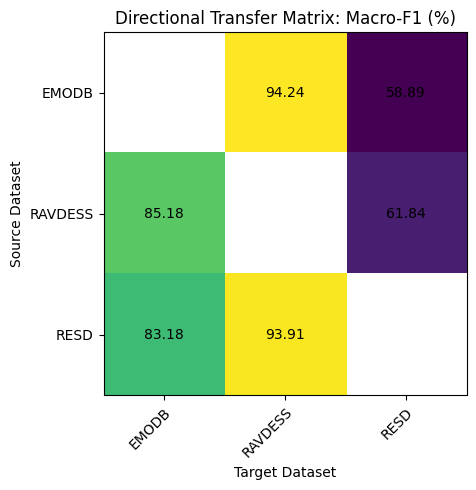

Saved: /content/drive/MyDrive/New Jurnal Cross/results_directional_transfer_emotion2vec_plus_base/directional_transfer_matrix_macro_f1.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

data = matrix_macro_f1.values.astype(float)
im = ax.imshow(data)

ax.set_xticks(np.arange(len(matrix_macro_f1.columns)))
ax.set_yticks(np.arange(len(matrix_macro_f1.index)))

ax.set_xticklabels(matrix_macro_f1.columns)
ax.set_yticklabels(matrix_macro_f1.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center")

ax.set_title("Directional Transfer Matrix: Macro-F1 (%)")
ax.set_xlabel("Target Dataset")
ax.set_ylabel("Source Dataset")

fig.tight_layout()

fig_path = OUT_DIR / "directional_transfer_matrix_macro_f1.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [11]:
manifest = {
    "analysis": "directional_transfer_matrix",
    "model": "emotion2vec MLP",
    "feature_dir": str(E2V_DIR),
    "output_dir": str(OUT_DIR),
    "pairs": [
        {
            "source": DATASET_LABEL[src],
            "target": DATASET_LABEL[tgt]
        }
        for src, tgt in pairs
    ],
    "protocol": {
        "source_train": "source train + source test",
        "source_validation": "source validation split",
        "target_test": "target train + target validation + target test",
        "scaler": "StandardScaler fitted only on source_train",
        "model_selection": "best epoch selected using source_validation Macro-F1",
        "target_usage": "target dataset used only for final test evaluation",
    },
    "seeds": SEEDS,
    "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "torch_version": pkg_ver("torch"),
    "numpy_version": pkg_ver("numpy"),
    "pandas_version": pkg_ver("pandas"),
    "scikit_learn_version": pkg_ver("scikit-learn"),
}

with open(OUT_DIR / "directional_transfer_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))
print("Saved:", OUT_DIR / "directional_transfer_manifest.json")

{
  "analysis": "directional_transfer_matrix",
  "model": "emotion2vec MLP",
  "feature_dir": "/content/drive/MyDrive/New Jurnal Cross/processed_intra_features_e2v_plus_base",
  "output_dir": "/content/drive/MyDrive/New Jurnal Cross/results_directional_transfer_emotion2vec_plus_base",
  "pairs": [
    {
      "source": "EMODB",
      "target": "RAVDESS"
    },
    {
      "source": "RAVDESS",
      "target": "EMODB"
    },
    {
      "source": "EMODB",
      "target": "RESD"
    },
    {
      "source": "RAVDESS",
      "target": "RESD"
    },
    {
      "source": "RESD",
      "target": "EMODB"
    },
    {
      "source": "RESD",
      "target": "RAVDESS"
    }
  ],
  "protocol": {
    "source_train": "source train + source test",
    "source_validation": "source validation split",
    "target_test": "target train + target validation + target test",
    "scaler": "StandardScaler fitted only on source_train",
    "model_selection": "best epoch selected using source_validation Macro-